# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

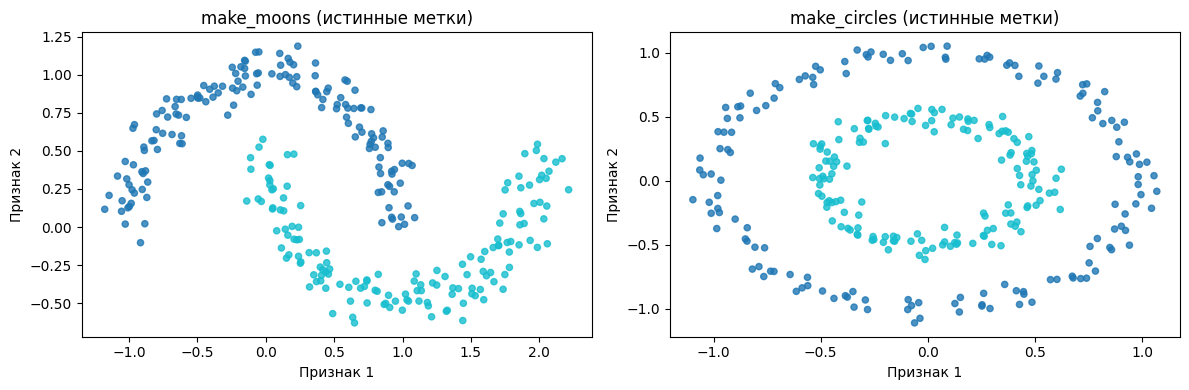

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

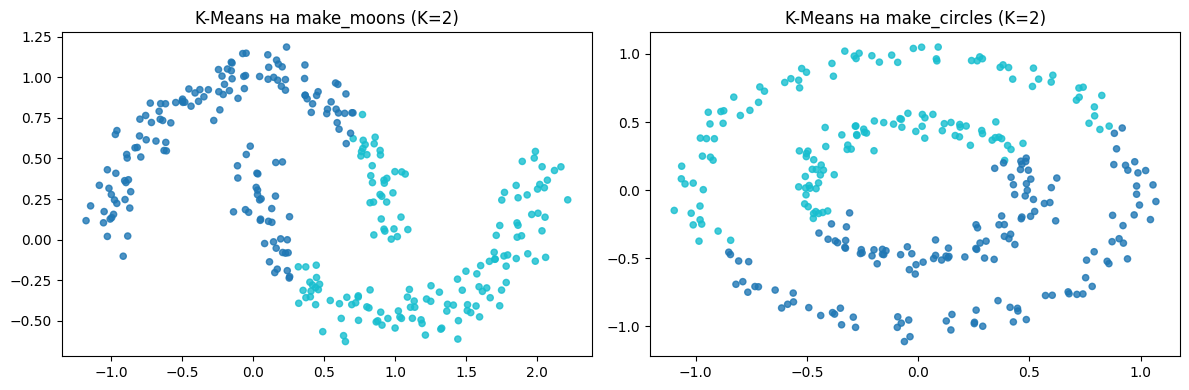

In [3]:
# Применим K-Means к этим датасетам
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

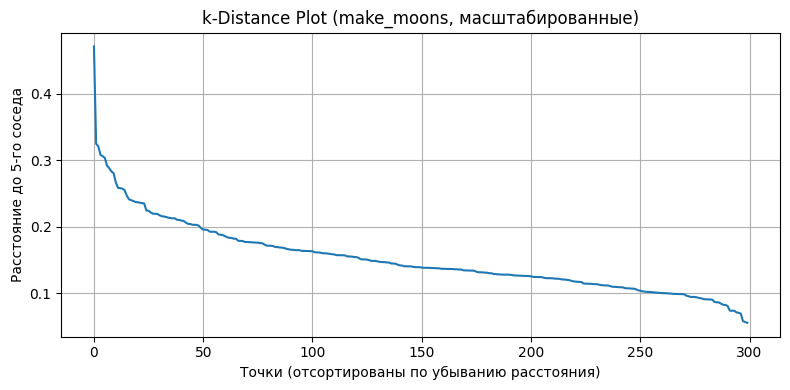

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [4]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию
nbrs_moons = NearestNeighbors(n_neighbors=k)
nbrs_moons.fit(X_moons_scaled)
distances_moons, _ = nbrs_moons.kneighbors(X_moons_scaled)
k_distances_moons = np.sort(distances_moons[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

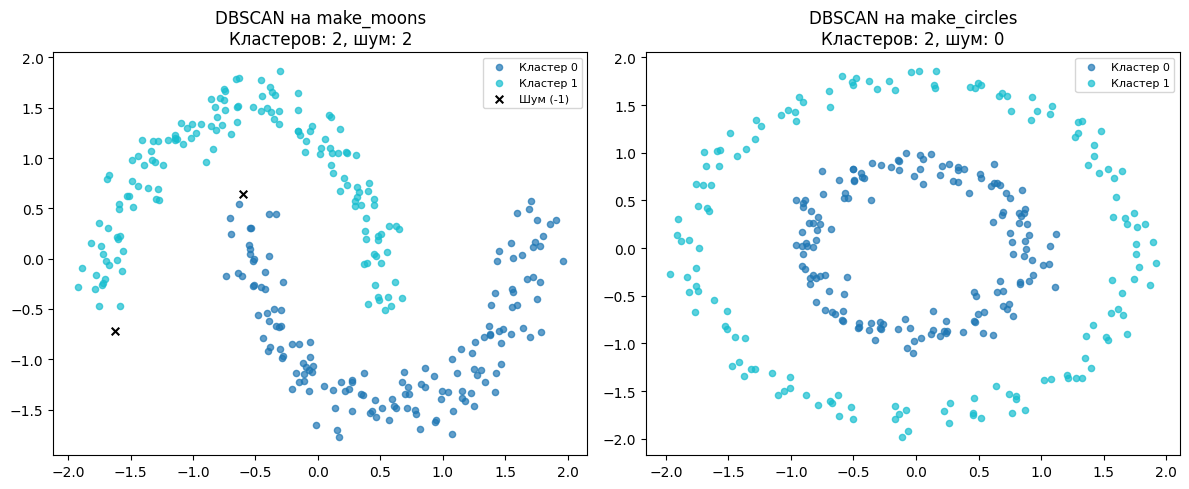

In [6]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера
db_moons = DBSCAN(eps=0.25, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.35, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    cluster_labels = sorted(label for label in set(labels) if label != -1)
    colors = cm.tab10(np.linspace(0, 1, max(cluster_labels) + 1)) if cluster_labels else []
    
    for label in cluster_labels:
        mask = labels == label
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[label % len(colors)], label=f'Кластер {label}')
    
    if noise_mask.any():
        ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
                   s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = len(cluster_labels)
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [7]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

score_kmeans = silhouette_score(X_moons_scaled, labels_km_moons)

mask_dbscan = labels_db_moons != -1
score_dbscan = None
if mask_dbscan.sum() > 1 and len(set(labels_db_moons[mask_dbscan])) > 1:
    score_dbscan = silhouette_score(X_moons_scaled[mask_dbscan], labels_db_moons[mask_dbscan])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.449
DBSCAN:        0.387


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

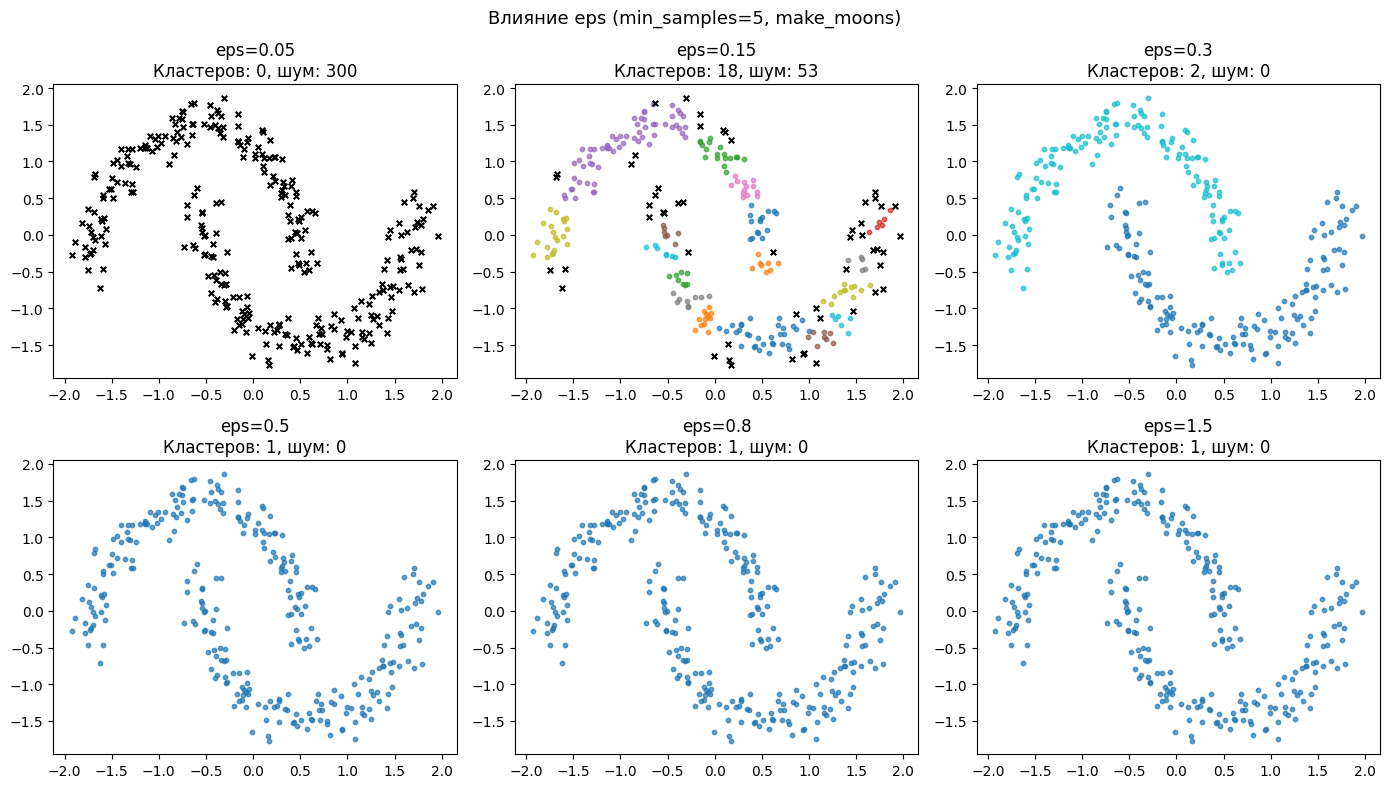

In [8]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    labels_i = DBSCAN(eps=eps_val, min_samples=5).fit_predict(X_moons_scaled)
    
    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()
    cluster_labels = sorted(label for label in set(labels_i) if label != -1)
    colors = cm.tab10(np.linspace(0, 1, max(cluster_labels) + 1)) if cluster_labels else []

    for label in cluster_labels:
        mask = labels_i == label
        axes[i].scatter(X_moons_scaled[mask, 0], X_moons_scaled[mask, 1],
                        c=[colors[label % len(colors)]], s=10, alpha=0.7)

    noise_mask = labels_i == -1
    if noise_mask.any():
        axes[i].scatter(X_moons_scaled[noise_mask, 0], X_moons_scaled[noise_mask, 1],
                        c='black', s=16, marker='x')

    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [9]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

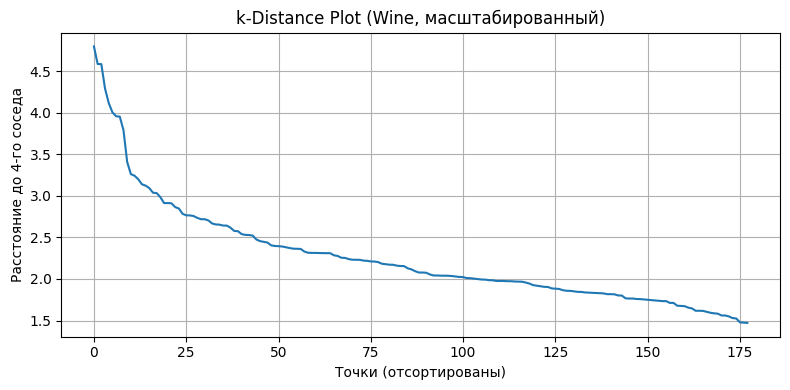

In [10]:
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

k_wine = 4
nbrs_wine = NearestNeighbors(n_neighbors=k_wine)
nbrs_wine.fit(X_wine_scaled)
distances_wine, _ = nbrs_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(distances_wine[:, -1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.4

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
noise_mask_wine = labels_wine == -1
n_noise_wine = int(noise_mask_wine.sum())
noise_share_wine = n_noise_wine / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"eps = {eps_wine}, min_samples = 4")
print(f"Число кластеров: {n_clusters_wine}")
print(f"Число шумовых точек: {n_noise_wine}")
print(f"Доля шума: {noise_share_wine:.2%}")

if n_clusters_wine > 1 and (~noise_mask_wine).sum() > 1:
    silhouette_wine_dbscan = silhouette_score(X_wine_scaled[~noise_mask_wine], labels_wine[~noise_mask_wine])
    print(f"Силуэт (без шума): {silhouette_wine_dbscan:.3f}")
else:
    silhouette_wine_dbscan = None
    print("Силуэт не вычислен: недостаточно кластеров без шума")

=== Результаты DBSCAN на Wine ===
eps = 2.4, min_samples = 4
Число кластеров: 2
Число шумовых точек: 33
Доля шума: 18.54%
Силуэт (без шума): 0.323


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [13]:
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine == -1   # маска для шумовых точек
X_wine_noise = pd.DataFrame(X_wine[noise_mask_wine], columns=feature_names)

print("=== Средние значения признаков ===")
if noise_mask_wine.any():
    mean_all = df_wine.mean()
    mean_noise = X_wine_noise.mean()
    compare_df = pd.DataFrame({
        'mean_all': mean_all,
        'mean_noise': mean_noise,
        'diff': mean_noise - mean_all,
        'abs_diff': (mean_noise - mean_all).abs()
    }).sort_values('abs_diff', ascending=False)
    print(compare_df[['mean_all', 'mean_noise', 'diff']].round(2).head(10))
else:
    print("Шумовых точек не найдено.")

=== Средние значения признаков ===
                              mean_all  mean_noise    diff
proline                         746.89      627.61 -119.29
magnesium                        99.74      102.88    3.14
alcalinity_of_ash                19.49       20.53    1.03
color_intensity                   5.06        4.18   -0.88
alcohol                          13.00       12.53   -0.47
proanthocyanins                   1.59        1.87    0.28
malic_acid                        2.34        2.45    0.11
total_phenols                     2.30        2.39    0.09
hue                               0.96        1.00    0.04
od280/od315_of_diluted_wines      2.61        2.59   -0.02


**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

=== Сравнение на Wine ===
DBSCAN silhouette: 0.323
K-Means silhouette: 0.285


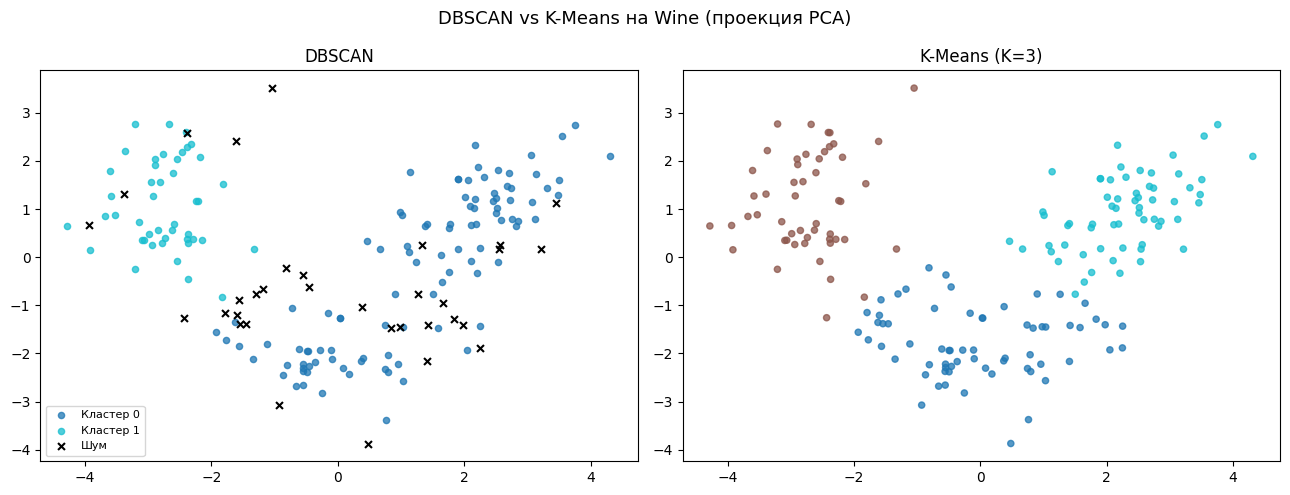

In [14]:
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

kmeans_wine = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_wine = kmeans_wine.fit_predict(X_wine_scaled)

silhouette_wine_kmeans = silhouette_score(X_wine_scaled, labels_kmeans_wine)

print("=== Сравнение на Wine ===")
print(f"DBSCAN silhouette: {silhouette_wine_dbscan:.3f}" if silhouette_wine_dbscan is not None else "DBSCAN silhouette: не вычислен")
print(f"K-Means silhouette: {silhouette_wine_kmeans:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
noise_mask_wine = labels_wine == -1
cluster_labels_wine = sorted(label for label in set(labels_wine) if label != -1)
colors_wine = cm.tab10(np.linspace(0, 1, max(cluster_labels_wine) + 1)) if cluster_labels_wine else []
for label in cluster_labels_wine:
    mask = labels_wine == label
    axes[0].scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1],
                    c=[colors_wine[label % len(colors_wine)]], s=20, alpha=0.75,
                    label=f'Кластер {label}')
if noise_mask_wine.any():
    axes[0].scatter(X_wine_2d[noise_mask_wine, 0], X_wine_2d[noise_mask_wine, 1],
                    c='black', s=25, marker='x', label='Шум')
axes[0].set_title('DBSCAN')
axes[0].legend(fontsize=8)

# K-Means
axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                c=labels_kmeans_wine, cmap='tab10', s=20, alpha=0.75)
axes[1].set_title('K-Means (K=3)')

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> DBSCAN выигрывает, когда кластеры имеют сложную, нелинейную форму, когда есть шум и выбросы, а также когда число кластеров заранее неизвестно.

**2. Когда K-Means предпочтительнее?**

> K-Means удобнее, когда кластеры примерно сферические, хорошо отделены друг от друга, шум минимален и нужно быстрое, простое решение.

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN опирается на расстояния между объектами. Если признаки имеют разные масштабы, один из них будет доминировать в метрике и исказит плотности, из-за чего eps станет плохо интерпретируемым.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки — это объекты с нетипичным сочетанием признаков. Это не обязательно "плохие" данные: они могут быть редкими образцами, пограничными случаями или реальными аномалиями.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Сравнивать можно только осторожно. У DBSCAN часть точек может быть помечена как шум, и если считать силуэт без них, сравнение идёт уже по разным подмножествам данных. Поэтому силуэт полезен, но не является абсолютно прямым и окончательным критерием качества.